# 02 — Model Comparison

Compares three shippable recommenders on a time-based split: popularity baseline, real item-item collaborative filtering, and matrix factorization trained with SGD. Neural matrix factorization is out of scope for this launch comparison; the recommendation below is based on models that are rerun end-to-end in the standard project pipeline.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..", "src").resolve()))

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from recsys.build_data import REVIEWS_CLEAN_PARQUET
from recsys.evaluate import rmse
from recsys.models import ItemBasedCF, MatrixFactorizationSGD, PopularityBaseline
from recsys.split import time_based_split

ROOT = Path("..").resolve()
OUTPUTS = ROOT / "outputs"
FIGURES = ROOT / "reports" / "figures"
OUTPUTS.mkdir(exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
SEED = 20260101
K = 10
N_EVAL_USERS = 100
SAMPLE_USERS = 5_000

reviews_full = pd.read_parquet(REVIEWS_CLEAN_PARQUET)
reviews_full["date"] = pd.to_datetime(reviews_full["date"])

# Deterministic user-level sample: select users, then keep every review for those users.
# This avoids row-level thinning and preserves enough per-user density for collaborative models.
rng = np.random.default_rng(SEED)
all_users = np.sort(reviews_full["user_id"].unique())
sampled_users = rng.choice(all_users, size=min(SAMPLE_USERS, len(all_users)), replace=False)
reviews = reviews_full.loc[reviews_full["user_id"].isin(sampled_users)].copy()
reviews = reviews.sort_values("date").reset_index(drop=True)
user_map = {user_id: idx for idx, user_id in enumerate(reviews["user_id"].unique())}
item_map = {business_id: idx for idx, business_id in enumerate(reviews["business_id"].unique())}
reviews["user_idx"] = reviews["user_id"].map(user_map).astype("int32")
reviews["item_idx"] = reviews["business_id"].map(item_map).astype("int32")
train, test = time_based_split(reviews, test_fraction=0.2)
n_users = int(reviews["user_idx"].max()) + 1
n_items = int(reviews["item_idx"].max()) + 1
ratings_per_user = len(reviews) / n_users
ratings_per_item = len(reviews) / n_items
print(f"full 5-core rows: {len(reviews_full):,}")
print(f"modeling sample: {n_users:,} users, {len(reviews):,} reviews, {n_items:,} restaurants")
print(f"sampling rule: deterministic user-level sample of up to {SAMPLE_USERS:,} users; all their reviews retained")
print(f"ratings per user: {ratings_per_user:.2f}; ratings per restaurant: {ratings_per_item:.2f}")
print(f"train rows: {len(train):,}; test rows: {len(test):,}")
print(f"split check: train max date {train['date'].max()} < test min date {test['date'].min()}")


full 5-core rows: 398,432
modeling sample: 5,000 users, 67,657 reviews, 8,200 restaurants
sampling rule: deterministic user-level sample of up to 5,000 users; all their reviews retained
ratings per user: 13.53; ratings per restaurant: 8.25
train rows: 54,125; test rows: 13,532
split check: train max date 2019-11-08 05:11:10 < test min date 2019-11-08 09:33:05


In [2]:
models = {
    "Popularity": PopularityBaseline().fit(train),
    "Item-item CF": ItemBasedCF(k_neighbors=30, shrinkage=25.0).fit(
        train, n_users=n_users, n_items=n_items
    ),
    "Matrix factorization": MatrixFactorizationSGD(
        n_users=n_users,
        n_items=n_items,
        n_factors=24,
        n_epochs=6,
        learning_rate=0.015,
        regularization=0.04,
        seed=SEED,
    ).fit(train),
}
models["Matrix factorization"].loss_history_


[1.2171565294265747,
 1.1498337984085083,
 1.1077989339828491,
 1.077141523361206,
 1.053318977355957,
 1.0338354110717773]

In [3]:
def recommendation_lists(model, train_df, test_df, n_items, k=10, n_eval_users=250, seed=SEED):
    rng = np.random.default_rng(seed)
    train_items_by_user = train_df.groupby("user_idx")["item_idx"].apply(set)
    test_items_by_user = test_df.groupby("user_idx")["item_idx"].apply(set)
    eval_users = test_items_by_user.index.to_numpy()
    if len(eval_users) > n_eval_users:
        eval_users = rng.choice(eval_users, size=n_eval_users, replace=False)

    rows = []
    hits = 0
    recommended_items = set()
    actual_k = min(k, n_items)
    for user_idx in eval_users:
        scores = model.score_all_items(int(user_idx), n_items).copy()
        seen = train_items_by_user.get(user_idx, set())
        if seen:
            scores[list(seen)] = -np.inf
        top_k = np.argpartition(-scores, actual_k - 1)[:actual_k]
        top_k = top_k[np.argsort(-scores[top_k])]
        recommended_items.update(top_k.tolist())
        user_hits = test_items_by_user[user_idx] & set(top_k.tolist())
        if user_hits:
            hits += 1
        for rank, item_idx in enumerate(top_k, start=1):
            rows.append(
                {
                    "user_idx": int(user_idx),
                    "item_idx": int(item_idx),
                    "rank": rank,
                    "score": float(scores[item_idx]),
                    "is_test_hit": int(item_idx in test_items_by_user[user_idx]),
                }
            )
    recs = pd.DataFrame(rows)
    metrics = {
        "n_eval_users": int(len(eval_users)),
        "hit_rate_at_10": hits / len(eval_users),
        "coverage": len(recommended_items) / n_items,
    }
    return recs, metrics

train_user_counts = train.groupby("user_idx").size().rename("user_train_count")
train_item_counts = train.groupby("item_idx").size().rename("item_train_count")
predictions = test[["review_id", "user_id", "business_id", "user_idx", "item_idx", "date", "stars"]].copy()
predictions = predictions.rename(columns={"stars": "y_true"})
predictions = predictions.merge(train_user_counts, on="user_idx", how="left")
predictions = predictions.merge(train_item_counts, on="item_idx", how="left")
predictions[["user_train_count", "item_train_count"]] = predictions[["user_train_count", "item_train_count"]].fillna(0).astype(int)

metric_rows = []
recommendation_frames = []
for name, model in models.items():
    pred = model.predict(test["user_idx"].to_numpy(), test["item_idx"].to_numpy())
    predictions[f"pred_{name}"] = pred
    recs, rank_metrics = recommendation_lists(model, train, test, n_items, K, N_EVAL_USERS)
    recs["model"] = name
    recommendation_frames.append(recs)
    metric_rows.append(
        {
            "model": name,
            "rmse": rmse(test["stars"].to_numpy(), pred),
            "hit_rate_at_10": rank_metrics["hit_rate_at_10"],
            "coverage": rank_metrics["coverage"],
            "n_eval_users": rank_metrics["n_eval_users"],
        }
    )

model_metrics = pd.DataFrame(metric_rows).sort_values(["hit_rate_at_10", "rmse"], ascending=[False, True])
recommendations = pd.concat(recommendation_frames, ignore_index=True)
model_metrics


,model,rmse,hit_rate_at_10,coverage,n_eval_users
0,Popularity,1.297605,0.10,0.001707,100
2,Matrix factorization,1.214195,0.03,0.011220,100
1,Item-item CF,1.313910,0.00,0.057439,100


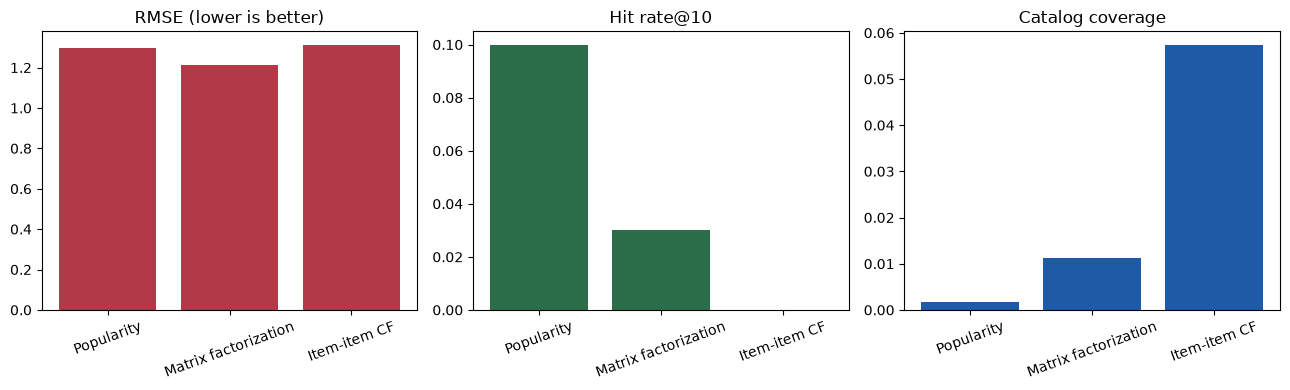

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
order = model_metrics["model"]
axes[0].bar(order, model_metrics.set_index("model").loc[order, "rmse"], color="#B23A48")
axes[0].set_title("RMSE (lower is better)")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(order, model_metrics.set_index("model").loc[order, "hit_rate_at_10"], color="#2C6E49")
axes[1].set_title("Hit rate@10")
axes[1].tick_params(axis="x", rotation=20)
axes[2].bar(order, model_metrics.set_index("model").loc[order, "coverage"], color="#1F5AA6")
axes[2].set_title("Catalog coverage")
axes[2].tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(FIGURES / "model_comparison.png", dpi=160)
plt.show()


In [5]:
item_lookup = reviews[["business_id", "item_idx"]].drop_duplicates()
user_lookup = reviews[["user_id", "user_idx"]].drop_duplicates()
model_metrics.to_csv(OUTPUTS / "model_metrics.csv", index=False)
predictions.to_parquet(OUTPUTS / "test_predictions.parquet", index=False)
recommendations.to_parquet(OUTPUTS / "recommendations.parquet", index=False)
item_lookup.to_parquet(OUTPUTS / "item_lookup.parquet", index=False)
user_lookup.to_parquet(OUTPUTS / "user_lookup.parquet", index=False)
summary = {
    "full_5_core_rows": int(len(reviews_full)),
    "sampling_rule": f"deterministic user-level sample of up to {SAMPLE_USERS:,} users; all reviews retained",
    "sample_rows": int(len(reviews)),
    "train_rows": int(len(train)),
    "test_rows": int(len(test)),
    "n_users": n_users,
    "n_items": n_items,
    "ratings_per_user": round(float(ratings_per_user), 2),
    "ratings_per_item": round(float(ratings_per_item), 2),
    "best_model": str(model_metrics.iloc[0]["model"]),
    "best_hit_rate_at_10": round(float(model_metrics.iloc[0]["hit_rate_at_10"]), 4),
    "best_rmse": round(float(model_metrics.iloc[0]["rmse"]), 4),
    "best_coverage": round(float(model_metrics.iloc[0]["coverage"]), 4),
    "mf_loss_history": [round(float(value), 4) for value in models["Matrix factorization"].loss_history_],
}
(OUTPUTS / "model_summary.json").write_text(json.dumps(summary, indent=2))
summary


{'full_5_core_rows': 398432,
 'sampling_rule': 'deterministic user-level sample of up to 5,000 users; all reviews retained',
 'sample_rows': 67657,
 'train_rows': 54125,
 'test_rows': 13532,
 'n_users': 5000,
 'n_items': 8200,
 'ratings_per_user': 13.53,
 'ratings_per_item': 8.25,
 'best_model': 'Popularity',
 'best_hit_rate_at_10': 0.1,
 'best_rmse': 1.2976,
 'best_coverage': 0.0017,
 'mf_loss_history': [1.2172, 1.1498, 1.1078, 1.0771, 1.0533, 1.0338]}